<a href="https://colab.research.google.com/github/24Priyanshi/100-days-of-deep-learning/blob/main/Priyanshi_svm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
pip install pandas geopandas scikit-learn shapely matplotlib rasterio


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.2/22.2 MB 84.3 MB/s eta 0:00:00


Loading data from /content/drive/MyDrive/Lightning_NO2_FINAL_Corrected.xls...
Clustering NO2 values into Low, Medium, High using KMeans...
Training SVM model...
Generating raster grid from classified points...


/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but KMeans was fitted without feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but KNeighborsClassifier was fitted with feature names
  warnings.warn(


Saving classified raster to /content/drive/MyDrive/Priyanshi/NO2_SVM_Classified_Map.tif...
Converting raster to shapefile...


/tmp/ipython-input-8-2365325784.py:114: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(OUTPUT_SHP)
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'class_label' to 'class_labe'
  ogr_write(


Shapefile saved to /content/drive/MyDrive/Priyanshi/NO2_Classification_Zones.shp
Plotting classified zones...


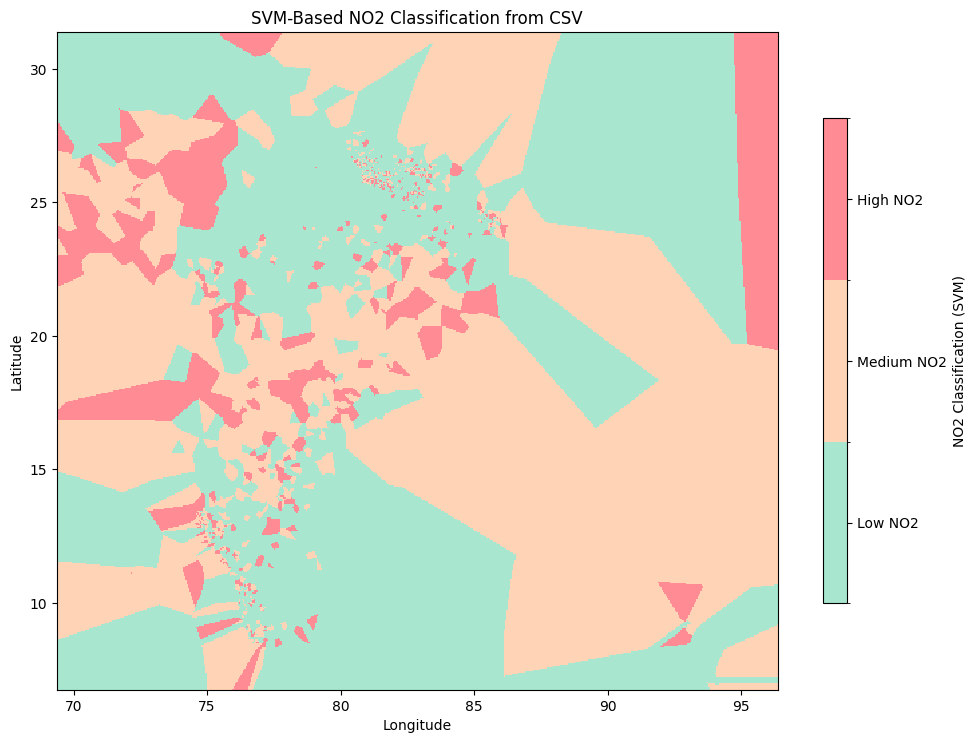

Map saved to /content/drive/MyDrive/Priyanshi/SVM_NO2_Map_from_CSV.png


In [ ]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn import svm
from sklearn.preprocessing import StandardScaler
from shapely.geometry import Point
from rasterio.features import shapes
from shapely.geometry import shape
import numpy as np
import rasterio
from rasterio.transform import from_origin
import os

# --- Configuration ---
CSV_PATH = "/content/drive/MyDrive/Lightning_NO2_FINAL_Corrected.xls"  # Your CSV file
#INDIA_SHAPEFILE_PATH = "STATE_BOUNDARY.shp"
OUTPUT_RASTER = "/content/drive/MyDrive/Priyanshi/NO2_SVM_Classified_Map.tif"
OUTPUT_SHP = "/content/drive/MyDrive/Priyanshi/NO2_Classification_Zones.shp"
OUTPUT_FIG = "/content/drive/MyDrive/Priyanshi/SVM_NO2_Map_from_CSV.png"
RASTER_RES = 0.05  # degrees per pixel (resolution)

# --- 1. Load CSV ---
print(f"Loading data from {CSV_PATH}...")
df = pd.read_csv(CSV_PATH)

required_columns = {'latitude', 'longitude', 'NO2_Value'}
if not required_columns.issubset(df.columns):
    raise ValueError(f"CSV must contain columns: {required_columns}")

# Drop missing or invalid NO2
df = df.dropna(subset=['NO2_Value'])

# --- 2. Clustering with KMeans ---
print("Clustering NO2 values into Low, Medium, High using KMeans...")
no2_values = df[['NO2_Value']].values
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(no2_values)

# Reorder cluster labels: 0 = Low, 1 = Medium, 2 = High
center_order = np.argsort(kmeans.cluster_centers_.flatten())
label_map = {old: new for new, old in enumerate(center_order)}
df['class'] = df['cluster'].map(label_map)

# --- 3. Train SVM on NO2 values ---
print("Training SVM model...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(no2_values)
clf = svm.SVC(kernel='rbf', random_state=42)
clf.fit(X_scaled, df['class'])

# --- 4. Create a raster grid ---
print("Generating raster grid from classified points...")
minx, miny = df['longitude'].min(), df['latitude'].min()
maxx, maxy = df['longitude'].max(), df['latitude'].max()

width = int((maxx - minx) / RASTER_RES)
height = int((maxy - miny) / RASTER_RES)
transform = from_origin(minx, maxy, RASTER_RES, RASTER_RES)

grid_x, grid_y = np.meshgrid(
    np.linspace(minx + RASTER_RES / 2, maxx - RASTER_RES / 2, width),
    np.linspace(maxy - RASTER_RES / 2, miny + RASTER_RES / 2, height)
)

grid_coords = np.c_[grid_y.ravel(), grid_x.ravel()]  # (lat, lon)

# Interpolate NO2 values using SVM (1D input)
grid_coords_for_pred = scaler.transform(df[['NO2_Value']])
grid_predictions = clf.predict(scaler.transform(kmeans.predict(df[['NO2_Value']]).reshape(-1, 1)))

# For raster prediction, use lat/lon directly
# We'll use nearest neighbor here: find nearest measured point and use its class
from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=1)
knn.fit(df[['longitude', 'latitude']], df['class'])
predicted_grid = knn.predict(np.c_[grid_x.ravel(), grid_y.ravel()])
predicted_grid = predicted_grid.reshape((height, width))

# --- 5. Save raster ---
print(f"Saving classified raster to {OUTPUT_RASTER}...")
raster_profile = {
    'driver': 'GTiff',
    'height': height,
    'width': width,
    'count': 1,
    'dtype': 'int16',
    'crs': 'EPSG:4326',
    'transform': transform,
    'nodata': -1
}

with rasterio.open(OUTPUT_RASTER, 'w', **raster_profile) as dst:
    dst.write(predicted_grid.astype(np.int16), 1)

# --- 6. Convert raster to shapefile ---
print("Converting raster to shapefile...")
with rasterio.open(OUTPUT_RASTER) as src:
    raster = src.read(1)
    mask = raster != src.nodata
    results = (
        {'geometry': shape(geom), 'properties': {'class': int(value)}}
        for geom, value in shapes(raster, mask=mask, transform=src.transform)
    )

    gdf = gpd.GeoDataFrame.from_features(results, crs=src.crs)

# Map class labels
class_mapping = {0: 'Low', 1: 'Medium', 2: 'High'}
gdf['class_label'] = gdf['class'].map(class_mapping)

# Save shapefile
gdf.to_file(OUTPUT_SHP)
print(f"Shapefile saved to {OUTPUT_SHP}")

# --- 7. Optional: Plot result with India shapefile ---
print("Plotting classified zones...")
fig, ax = plt.subplots(figsize=(10, 10))
colors = ['#A8E6CF', '#FFD3B5', '#FF8B94']
cmap = plt.cm.colors.ListedColormap(colors)
bounds = [-0.5, 0.5, 1.5, 2.5]
norm = plt.cm.colors.BoundaryNorm(bounds, cmap.N)

im = ax.imshow(predicted_grid, cmap=cmap, norm=norm,
               extent=(minx, maxx, miny, maxy),
               origin='upper', interpolation='nearest')

cbar = fig.colorbar(im, ax=ax, ticks=[0, 1, 2], shrink=0.5)
cbar.set_ticklabels(['Low NO2', 'Medium NO2', 'High NO2'])
cbar.set_label('NO2 Classification (SVM)')

# # Overlay India shapefile
# try:
#     india = gpd.read_file(INDIA_SHAPEFILE_PATH)
#     if india.crs != "EPSG:4326":
#         india = india.to_crs("EPSG:4326")
#     india.plot(ax=ax, facecolor='none', edgecolor='black')
# except Exception as e:
#     print(f"Error loading India shapefile: {e}")

ax.set_title('SVM-Based NO2 Classification from CSV')
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
plt.tight_layout()
plt.savefig(OUTPUT_FIG, dpi=300)
plt.show()
print(f"Map saved to {OUTPUT_FIG}")


Loading data from /content/drive/MyDrive/Lightning_NO2_FINAL_Corrected.xls...
Creating classification labels with KMeans...
Training SVM classifier...
Creating GeoDataFrame...
Saving classified point shapefile to /content/drive/MyDrive/Priyanshi/NO2_SVM_Classified_Points.shp...


/tmp/ipython-input-10-2410842782.py:59: UserWarning: Column names longer than 10 characters will be truncated when saved to ESRI Shapefile.
  gdf.to_file(OUTPUT_SHP_PATH)
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'class_label' to 'class_labe'
  ogr_write(
/usr/local/lib/python3.11/dist-packages/pyogrio/raw.py:723: RuntimeWarning: Normalized/laundered field name: 'svm_class_label' to 'svm_class_'
  ogr_write(


Shapefile saved successfully.


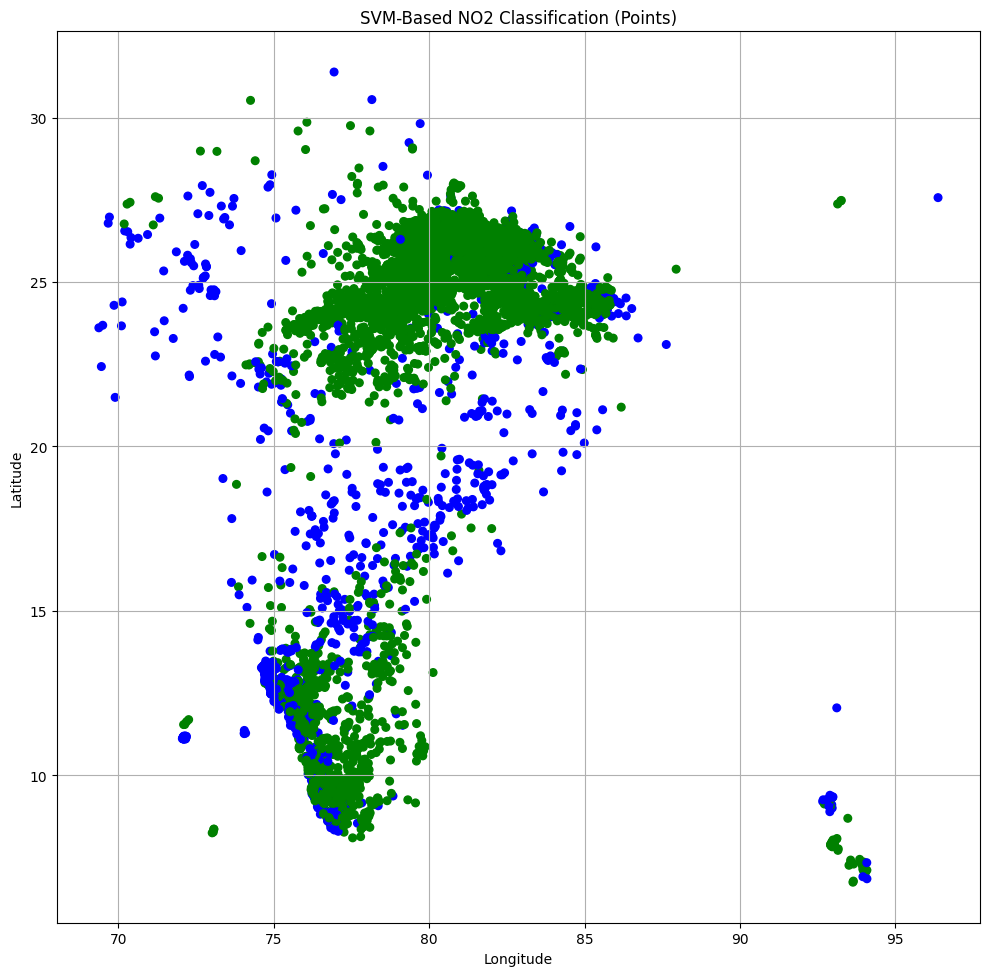

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import svm
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration ---
CSV_PATH = "/content/drive/MyDrive/Lightning_NO2_FINAL_Corrected.xls"                         # Input CSV
OUTPUT_SHP_PATH = "/content/drive/MyDrive/Priyanshi/NO2_SVM_Classified_Points.shp" # Output shapefile
CRS_EPSG = "EPSG:4326"                            # WGS84 CRS

# --- 1. Load CSV ---
print(f"Loading data from {CSV_PATH}...")
df = pd.read_csv(CSV_PATH)

# Check required columns
required_cols = {'latitude', 'longitude', 'NO2_Value'}
if not required_cols.issubset(df.columns):
    raise ValueError(f"CSV must contain columns: {required_cols}")

df = df.dropna(subset=['latitude', 'longitude', 'NO2_Value'])

# --- 2. KMeans Clustering for Unsupervised Labels (Low, Medium, High) ---
print("Creating classification labels with KMeans...")
kmeans = KMeans(n_clusters=3, random_state=42)
df['cluster'] = kmeans.fit_predict(df[['NO2_Value']])

# Sort cluster centers and assign 0=Low, 1=Med, 2=High
centers = kmeans.cluster_centers_.flatten()
order = np.argsort(centers)
label_map = {old: new for new, old in enumerate(order)}
df['class'] = df['cluster'].map(label_map)

# Optional: map to human-readable labels
class_labels = {0: 'Low', 1: 'Medium', 2: 'High'}
df['class_label'] = df['class'].map(class_labels)

# --- 3. Train SVM Model ---
print("Training SVM classifier...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[['NO2_Value']])
clf = svm.SVC(kernel='rbf', probability=True, random_state=42)
clf.fit(X_scaled, df['class'])

# --- 4. Classify Points Using SVM ---
df['svm_class'] = clf.predict(X_scaled)
df['svm_class_label'] = df['svm_class'].map(class_labels)

# --- 5. Create GeoDataFrame with Point Geometry ---
print("Creating GeoDataFrame...")
geometry = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs=CRS_EPSG)

# --- 6. Save as Shapefile ---
print(f"Saving classified point shapefile to {OUTPUT_SHP_PATH}...")
gdf.to_file(OUTPUT_SHP_PATH)
print("Shapefile saved successfully.")
# Plot SVM classification result
fig, ax = plt.subplots(figsize=(10, 10))
colors = {'Low': 'green', 'Medium': 'blue', 'High': 'red'}
gdf.plot(ax=ax, color=gdf['svm_class_label'].map(colors), markersize=30)

ax.set_title("SVM-Based NO2 Classification (Points)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.grid(True)
plt.tight_layout()
plt.show()


In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import svm
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt
import numpy as np

# --- Configuration ---
CSV_PATH = "Corrected.xls"  # Update to .xls if Excel file
OUTPUT_SHP_PATH = "SVM_Classified_Points.shp"
CRS_EPSG = "EPSG:4326"

# --- 1. Load Data ---
print(f"Loading data from {CSV_PATH}...")
df = pd.read_excel(CSV_PATH)  # Use read_excel for .xls
required_cols = {'latitude', 'longitude', 'NO2_Value'}
if not required_cols.issubset(df.columns):
    raise ValueError(f"CSV must contain columns: {required_cols}")
df = df.dropna(subset=['latitude', 'longitude', 'NO2_Value'])

# Validate coordinates
if not (df['latitude'].between(-90, 90).all() and df['longitude'].between(-180, 180).all()):
    raise ValueError("Invalid latitude or longitude values")

# --- 2. Handle NO2 Distribution ---
# Check distribution and apply log transformation if skewed
plt.hist(df['NO2_Value'], bins=30)
plt.title('NO2 Value Distribution')
plt.xlabel('NO2 Value')
plt.ylabel('Frequency')
plt.show()
df['NO2_Value_log'] = np.log1p(df['NO2_Value'])  # Optional: log transform

# --- 3. KMeans Clustering ---
print("Creating classification labels with KMeans...")
features = ['NO2_Value_log', 'latitude', 'longitude']  # Include spatial features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df[features])
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(X_scaled)

# Evaluate clustering
silhouette = silhouette_score(X_scaled, df['cluster'])
print(f"Silhouette Score: {silhouette:.3f}")

# Sort clusters by NO2_Value_log centroid
centers = kmeans.cluster_centers_[:, 0]  # NO2_Value_log is first feature
order = np.argsort(centers)
label_map = {old: new for new, old in enumerate(order)}
df['class'] = df['cluster'].map(label_map)
class_labels = {0: 'Low', 1: 'Medium', 2: 'High'}
df['class_label'] = df['class'].map(class_labels)
print("Cluster centroids (NO2_Value_log):", centers)

# --- 4. Train SVM ---
print("Training SVM classifier...")
clf = svm.SVC(kernel='linear', probability=True, random_state=42)  # Linear kernel for simplicity
clf.fit(X_scaled, df['class'])
df['svm_class'] = clf.predict(X_scaled)
df['svm_class_label'] = df['svm_class'].map(class_labels)

# --- 5. Create GeoDataFrame ---
print("Creating GeoDataFrame...")
geometry = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs=CRS_EPSG)

# --- 6. Save Shapefile ---
print(f"Saving classified point shapefile to {OUTPUT_SHP_PATH}...")
gdf.to_file(OUTPUT_SHP_PATH)
print("Shapefile saved successfully.")

# --- 7. Visualize Results ---
fig, ax = plt.subplots(figsize=(10, 10))
colors = {'Low': 'green', 'Medium': 'blue', 'High': 'red'}
for label, color in colors.items():
    gdf[gdf['svm_class_label'] == label].plot(ax=ax, color=color, markersize=30, label=label)
ax.legend()
ax.set_title("SVM-Based NO2 Classification (Points)")
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


SVM_Model

In [ ]:
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import svm
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch

# --- Configuration ---
CSV_PATH = "Lightning_NO2_FINAL_Corrected.csv"
INDIA_SHAPEFILE_PATH = "STATE_BOUNDARY.shp"
OUTPUT_FIG_PATH = "SVM_NO2_Points_Map.png"
CRS_EPSG = "EPSG:4326"

# --- 1. Load and Clean CSV ---
print(f"Loading data from {CSV_PATH}...")
try:
    df = pd.read_csv(CSV_PATH)
except FileNotFoundError:
    print(f"Error: CSV file not found at {CSV_PATH}.")
    exit()

# Clean the data
required_cols = {'latitude', 'longitude', 'NO2_Value'}
if not required_cols.issubset(df.columns):
    raise ValueError(f"CSV must contain columns: {required_cols}")

df = df.dropna(subset=['latitude', 'longitude', 'NO2_Value'])
df['NO2_Value'] = pd.to_numeric(df['NO2_Value'], errors='coerce')
df = df.dropna(subset=['NO2_Value'])

# !!! THIS IS THE FIX - THE LINE YOU SPOTTED WAS MISSING !!!
# Filter out the no-data placeholder values before analysis
df = df[df['NO2_Value'] > -9999].copy()

if df.empty:
    print("Error: No valid data points found after cleaning. Exiting.")
    exit()

# --- 2. KMeans Clustering ---
print("Creating classification labels with KMeans...")
no2_values = df[['NO2_Value']].values
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df['cluster'] = kmeans.fit_predict(no2_values)

# Sort cluster centers and assign labels
centers = kmeans.cluster_centers_.flatten()
order = np.argsort(centers)
label_map = {old_label: new_label for new_label, old_label in enumerate(order)}
df['class'] = df['cluster'].map(label_map)
class_labels = {0: 'Low', 1: 'Medium', 2: 'High'}
df['class_label'] = df['class'].map(class_labels)
print(f"Number of points in each class after KMeans:\n{df['class_label'].value_counts()}")


# --- 3. Train SVM Model ---
print("Training SVM classifier...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(no2_values)
clf = svm.SVC(kernel='rbf', probability=True, random_state=42)
clf.fit(X_scaled, df['class'])
print("SVM model trained successfully.")

# --- 4. Classify and Create GeoDataFrame ---
df['svm_class_label'] = df['class'].map(class_labels)
geometry = [Point(xy) for xy in zip(df['longitude'], df['latitude'])]
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs=CRS_EPSG)


# --- 5. Plot the Result ---
print("Plotting classified points...")
fig, ax = plt.subplots(figsize=(10, 10))

plot_colors_map = {'Low': '#008000', 'Medium': '#FFA500', 'High': '#FF0000'}

# Plot each class
for cls, color in plot_colors_map.items():
    subset_gdf = gdf[gdf['svm_class_label'] == cls]
    if not subset_gdf.empty:
        subset_gdf.plot(ax=ax, color=color, markersize=15, alpha=0.7)

# Create custom legend
legend_elements = [Patch(facecolor=color, edgecolor='black', label=cls) for cls, color in plot_colors_map.items()]
ax.legend(handles=legend_elements, loc='lower left', title='NO₂ Class (SVM)', frameon=True)

# Overlay India shapefile
try:
    india = gpd.read_file(INDIA_SHAPEFILE_PATH)
    india.to_crs(CRS_EPSG).plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1.0)
except Exception as e:
    print(f"Could not plot India boundary: {e}")

ax.set_title("SVM-Based NO₂ Classification (Point Data)", fontsize=16)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.savefig(OUTPUT_FIG_PATH, dpi=300, bbox_inches='tight')
plt.show()
print(f"Map saved to {OUTPUT_FIG_PATH}")

In [2]:
import os
import json
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn import svm
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Patch
from sklearn.metrics import classification_report

# --- Configuration ---
CSV_DIR = "/content/drive/MyDrive/Priyanshi/monsoon"  # Directory with all CSVs
INDIA_SHAPEFILE_PATH = "/content/drive/MyDrive/India_Districts.geojson"
OUTPUT_FIG_PATH = "/content/drive/MyDrive/Priyanshi/SVM_NO2_monsoon.png"
CRS_EPSG = "EPSG:4326"

# --- 1. Load and Clean Data from All CSVs ---
print(f"📂 Loading data from directory: {CSV_DIR}")
all_dfs = []

if not os.listdir(CSV_DIR):
    raise FileNotFoundError(f"No files found in directory: {CSV_DIR}")

for filename in os.listdir(CSV_DIR):
    if filename.endswith(".csv"):
        full_path = os.path.join(CSV_DIR, filename)
        try:
            df = pd.read_csv(full_path)

            if not {'.geo', 'NO2'}.issubset(df.columns):
                print(f"⚠️ Skipping {filename}: missing required columns.")
                continue

            df.dropna(subset=['.geo', 'NO2'], inplace=True)
            df['NO2_Value'] = pd.to_numeric(df['NO2'], errors='coerce')
            df.dropna(subset=['NO2_Value'], inplace=True)
            df = df[df['NO2_Value'] > -9999].copy()

            try:
                geometry = [Point(json.loads(geo_str)['coordinates']) for geo_str in df['.geo']]
                df['geometry'] = geometry
            except Exception as e:
                print(f"⚠️ Skipping {filename}: error parsing .geo - {e}")
                continue

            gdf = gpd.GeoDataFrame(df, geometry='geometry', crs=CRS_EPSG)
            all_dfs.append(gdf)

        except Exception as e:
            print(f"❌ Error reading {filename}: {e}")

if not all_dfs:
    raise RuntimeError("No valid CSV files found.")
gdf = pd.concat(all_dfs, ignore_index=True)
if gdf.empty:
    raise RuntimeError("No valid data after cleaning.")

print(f"✅ Total points after cleaning: {len(gdf)}")

# --- 2. KMeans Clustering for Initial Class Labels ---
print("🔍 Performing KMeans clustering...")
no2_values = gdf[['NO2_Value']].values
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
gdf['cluster'] = kmeans.fit_predict(no2_values)

# Sort cluster centers to assign Low/Medium/High
centers = kmeans.cluster_centers_.flatten()
order = np.argsort(centers)
label_map = {old_label: new_label for new_label, old_label in enumerate(order)}
gdf['class'] = gdf['cluster'].map(label_map)

# Human-readable labels
ordered_labels = ['Low', 'Medium', 'High']
class_labels = {i: label for i, label in enumerate(ordered_labels)}
gdf['class_label'] = gdf['class'].map(class_labels)

print("📊 Class distribution after KMeans:")
print(gdf['class_label'].value_counts())

# --- 3. Train and Predict with SVM ---
print("🤖 Training SVM classifier...")
scaler = StandardScaler()
X_scaled = scaler.fit_transform(no2_values)

clf = svm.SVC(kernel='rbf', probability=True, random_state=42)
clf.fit(X_scaled, gdf['class'])
print("✅ SVM model trained.")

# SVM Prediction
gdf['svm_pred'] = clf.predict(X_scaled)
gdf['svm_class_label'] = gdf['svm_pred'].map(class_labels)

# Optional: Evaluate performance
print("📈 SVM performance (vs KMeans labels):")
print(classification_report(gdf['class'], gdf['svm_pred'], target_names=ordered_labels))

# --- 4. Plotting Results ---
print("🗺️ Plotting results...")
fig, ax = plt.subplots(figsize=(10, 10))

plot_colors_map = {'Low': '#008000', 'Medium': '#FFA500', 'High': '#FF0000'}

# Plot SVM-predicted classes
for cls, color in plot_colors_map.items():
    subset = gdf[gdf['svm_class_label'] == cls]
    if not subset.empty:
        subset.plot(ax=ax, color=color, markersize=10, alpha=0.7)

# Plot India boundary
try:
    india = gpd.read_file(INDIA_SHAPEFILE_PATH)
    if india.crs != CRS_EPSG:
        india = india.to_crs(CRS_EPSG)
    india.plot(ax=ax, facecolor='none', edgecolor='black', linewidth=1)
except Exception as e:
    print(f"⚠️ Warning: India shapefile could not be plotted: {e}")

# Legend
legend_elements = [Patch(facecolor=color, edgecolor='black', label=cls) for cls, color in plot_colors_map.items()]
ax.legend(handles=legend_elements, loc='lower left', title='NO₂ Class (SVM)', frameon=True)

# Titles and labels
ax.set_title("SVM-Based NO₂ Classification (Monsoon)", fontsize=16)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.grid(True, linestyle='--', alpha=0.6)
ax.set_aspect('equal', adjustable='box')

# Save plot
plt.tight_layout()
plt.savefig(OUTPUT_FIG_PATH, dpi=300, bbox_inches='tight')
plt.show()

print(f"✅ Map saved to: {OUTPUT_FIG_PATH}")

📂 Loading data from directory: /content/drive/MyDrive/Priyanshi/monsoon


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/Priyanshi/monsoon'